# Task II — Quark vs Gluon Jet Classification with GNNs

Binary classification of jets (quark / gluon) using Graph Neural Networks on the ParticleNet dataset.
We compare two architectures: **GCN** (Graph Convolutional Network) and **GAT** (Graph Attention Network).

**Shared pipeline:**
- Feature engineering: `log(pT)`, coordinates relative to the pT-weighted centroid, standardization
- kNN graph in (eta, phi) space
- BatchNorm, Dropout, skip connections, mean+max pooling
- AdamW + cosine scheduler + early stopping

## 1. Imports and setup

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GATConv, BatchNorm,
    global_mean_pool, global_max_pool, knn_graph
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import time
import copy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Device: cpu


## 2. Loading the data

In [2]:
filepath = '/Users/ahmed/Downloads/QG_jets_1.npz'  # adjust path as needed
raw = np.load(filepath)

X_all = raw['X']  # (N, 134, 4): pT, eta, phi, pdgid
y_all = raw['y']  # (N,):        0=gluon, 1=quark

print(f"Jets: {X_all.shape[0]:,}")
print(f"Max particles/jet: {X_all.shape[1]}")
print(f"Features/particle: {X_all.shape[2]}")

unique, counts = np.unique(y_all, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Gluon' if u == 0 else 'Quark'
    print(f"  {label} (y={u}): {c:,} ({100*c/len(y_all):.1f}%)")

Jets: 100,000
Max particles/jet: 134
Features/particle: 4
  Gluon (y=0.0): 50,000 (50.0%)
  Quark (y=1.0): 50,000 (50.0%)


## 3. Feature engineering & graph construction

Each jet is a variable-length set of particles (a point cloud). To turn it into a graph we need two things: **node features** and **edges**.

For the node features, we apply a few standard transformations:
- `log(pT + 1)` to compress the very skewed transverse momentum distribution
- `delta_eta`, `delta_phi` relative to the pT-weighted centroid of the jet, so the network sees relative positions rather than absolute detector coordinates
- Standard normalization (mean/std computed on the training set only)

For the edges, we build a **kNN graph** (k=7) in the (eta, phi) plane. This is a natural choice since nearby particles in eta-phi are more likely to be physically related (e.g. from the same parton shower branch). The alternative would be a fully connected graph, but that doesn't scale well with particle multiplicity and introduces a lot of noise from distant, unrelated particles.

In [3]:
def compute_norm_stats(X, n):
    """Compute mean/std over the first n jets (should be train set only)."""
    all_feats = []
    for i in range(n):
        jet = X[i]
        mask = jet[:, 0] > 0
        if mask.sum() == 0:
            continue
        p = jet[mask]
        log_pt = np.log(p[:, 0] + 1)
        w = p[:, 0] / p[:, 0].sum()
        eta_c = np.average(p[:, 1], weights=w)
        phi_c = np.average(p[:, 2], weights=w)
        d_eta = p[:, 1] - eta_c
        d_phi = np.arctan2(np.sin(p[:, 2] - phi_c), np.cos(p[:, 2] - phi_c))
        all_feats.append(np.stack([log_pt, d_eta, d_phi, p[:, 3]], axis=1))
    all_feats = np.concatenate(all_feats, axis=0)
    mean = all_feats.mean(axis=0).astype(np.float32)
    std  = all_feats.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    return mean, std


def build_jet_graph(jet_raw, label, k=7, norm_mean=None, norm_std=None):
    """Convert a raw jet (numpy) into a PyG Data object."""
    mask = jet_raw[:, 0] > 0
    p = jet_raw[mask]
    n = len(p)
    if n == 0:
        return None

    log_pt = np.log(p[:, 0] + 1)
    w = p[:, 0] / p[:, 0].sum()
    eta_c = np.average(p[:, 1], weights=w)
    phi_c = np.average(p[:, 2], weights=w)
    d_eta = p[:, 1] - eta_c
    d_phi = np.arctan2(np.sin(p[:, 2] - phi_c), np.cos(p[:, 2] - phi_c))

    feats = np.stack([log_pt, d_eta, d_phi, p[:, 3]], axis=1).astype(np.float32)
    if norm_mean is not None:
        feats = (feats - norm_mean) / norm_std

    x = torch.tensor(feats, dtype=torch.float)
    coords = torch.tensor(np.stack([d_eta, d_phi], axis=1), dtype=torch.float)
    real_k = min(k, n - 1)
    edge_index = knn_graph(coords, k=real_k, loop=False) if real_k > 0 else torch.empty((2, 0), dtype=torch.long)
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)


class JetDataset(Dataset):
    def __init__(self, X, y, k=7, norm_mean=None, norm_std=None):
        super().__init__()
        self.X, self.y, self.k = X, y, k
        self.norm_mean, self.norm_std = norm_mean, norm_std

    def len(self):
        return len(self.y)

    def get(self, idx):
        g = build_jet_graph(self.X[idx], self.y[idx], self.k, self.norm_mean, self.norm_std)
        return g if g is not None else self.get((idx + 1) % self.len())

## 4. Train / Validation / Test split

In [4]:
indices = np.random.permutation(len(X_all))
n = len(X_all)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

idx_train = indices[:n_train]
idx_val   = indices[n_train:n_train + n_val]
idx_test  = indices[n_train + n_val:]

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val,   y_val   = X_all[idx_val],   y_all[idx_val]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

norm_mean, norm_std = compute_norm_stats(X_train, len(X_train))
print(f"Norm mean: {norm_mean}")
print(f"Norm std:  {norm_std}")

Train: 70,000  |  Val: 15,000  |  Test: 15,000
Norm mean: [1.7574639e+00 1.6723824e-04 5.9855101e-05 1.5523958e+01]
Norm std:  [1.17973101e+00 1.22449234e-01 1.22229487e-01 5.62074890e+02]


In [5]:
K = 7
BS = 128

train_ds = JetDataset(X_train, y_train, K, norm_mean, norm_std)
val_ds   = JetDataset(X_val,   y_val,   K, norm_mean, norm_std)
test_ds  = JetDataset(X_test,  y_test,  K, norm_mean, norm_std)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BS, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BS, shuffle=False, num_workers=0)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches — train: 547, val: 118, test: 118


## 5. Model architectures: GCN and GAT

Both models share the same overall structure so the comparison is fair:
- 3 graph convolution layers
- BatchNorm + ELU + Dropout after each layer
- Skip connections (residual)
- Combined mean + max pooling
- 2-layer MLP classifier

The only difference is the convolution type (GCNConv vs GATConv with 4 attention heads).

In [6]:
class GCNModel(torch.nn.Module):
    """GCN with 3 layers and skip connections."""

    def __init__(self, in_features=4, hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden)
        self.bn1   = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2   = BatchNorm(hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn3   = BatchNorm(hidden)

        self.proj_in = torch.nn.Linear(in_features, hidden)  # project input dim to hidden for the first skip

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden, 2)
        )
        self.dropout = dropout

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch

        h = self.bn1(self.conv1(x, ei))
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = h + self.proj_in(x)  # skip from input

        h2 = self.bn2(self.conv2(h, ei))
        h2 = F.elu(h2)
        h2 = F.dropout(h2, p=self.dropout, training=self.training)
        h2 = h2 + h  # skip

        h3 = self.bn3(self.conv3(h2, ei))
        h3 = F.elu(h3)
        h3 = h3 + h2  # skip

        # mean + max pooling gives a richer graph-level representation
        out = torch.cat([global_mean_pool(h3, batch), global_max_pool(h3, batch)], dim=1)
        return self.mlp(out)


class GATModel(torch.nn.Module):
    """GAT with 3 layers, 4 attention heads, skip connections."""

    def __init__(self, in_features=4, hidden=128, heads=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATConv(in_features, hidden, heads=heads, concat=False, dropout=dropout)
        self.bn1  = BatchNorm(hidden)
        self.gat2 = GATConv(hidden, hidden, heads=heads, concat=False, dropout=dropout)
        self.bn2  = BatchNorm(hidden)
        self.gat3 = GATConv(hidden, hidden, heads=heads, concat=False, dropout=dropout)
        self.bn3  = BatchNorm(hidden)

        self.proj_in = torch.nn.Linear(in_features, hidden)

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden, 2)
        )
        self.dropout = dropout

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch

        h = self.bn1(self.gat1(x, ei))
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = h + self.proj_in(x)

        h2 = self.bn2(self.gat2(h, ei))
        h2 = F.elu(h2)
        h2 = F.dropout(h2, p=self.dropout, training=self.training)
        h2 = h2 + h

        h3 = self.bn3(self.gat3(h2, ei))
        h3 = F.elu(h3)
        h3 = h3 + h2

        out = torch.cat([global_mean_pool(h3, batch), global_max_pool(h3, batch)], dim=1)
        return self.mlp(out)


# quick check
gcn = GCNModel()
gat = GATModel()
print(f"GCN params: {sum(p.numel() for p in gcn.parameters() if p.requires_grad):,}")
print(f"GAT params: {sum(p.numel() for p in gat.parameters() if p.requires_grad):,}")
del gcn, gat

GCN params: 68,226
GAT params: 171,138


## 6. Training and evaluation utilities

In [7]:
EPOCHS       = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 5


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.y.size(0)
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch)
        loss = criterion(out, batch.y)
        total_loss += loss.item() * batch.y.size(0)
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.y.size(0)
    return total_loss / total, correct / total


def run_training(model, name):
    """Full training loop with early stopping. Returns the best model + history."""
    print(f"\n{'='*60}")
    print(f"  TRAINING: {name}")
    print(f"{'='*60}")

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = torch.nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>10} | {'Val Acc':>9} | {'LR':>10}")
    print('-' * 68)

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion)
        vl, va = evaluate(model, val_loader, criterion)
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        star = ''
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            star = ' *'
        else:
            patience_counter += 1

        print(f"{epoch:3d} | {tl:10.4f} | {ta:8.2%} | {vl:10.4f} | {va:8.2%} | {lr:10.6f}{star}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    elapsed = time.time() - t0
    print(f"Training time: {elapsed/60:.1f} min")

    model.load_state_dict(best_state)
    return model, history

## 7. Training both models

In [8]:
# fix seed before each model so initial weights are comparable
torch.manual_seed(SEED)
model_gcn, hist_gcn = run_training(GCNModel(), 'GCN')

torch.manual_seed(SEED)
model_gat, hist_gat = run_training(GATModel(), 'GAT')


  TRAINING: GCN
 Ep | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
--------------------------------------------------------------------
  1 |     0.5070 |   75.74% |     0.4731 |   79.04% |   0.000994 *
  2 |     0.4773 |   77.84% |     0.4591 |   79.75% |   0.000976 *
  3 |     0.4676 |   78.69% |     0.4892 |   76.59% |   0.000946
  4 |     0.4612 |   78.91% |     0.4678 |   78.17% |   0.000905
  5 |     0.4547 |   79.35% |     0.4571 |   79.32% |   0.000854 *
  6 |     0.4533 |   79.48% |     0.4899 |   76.72% |   0.000794
  7 |     0.4503 |   79.57% |     0.4686 |   78.45% |   0.000727
  8 |     0.4482 |   79.77% |     0.5127 |   74.43% |   0.000655
  9 |     0.4454 |   79.87% |     0.4654 |   78.27% |   0.000578
 10 |     0.4441 |   79.90% |     0.5269 |   72.92% |   0.000500
Early stopping at epoch 10
Training time: 11.4 min

  TRAINING: GAT
 Ep | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
--------------------------------------------------------

## 8. Training curves

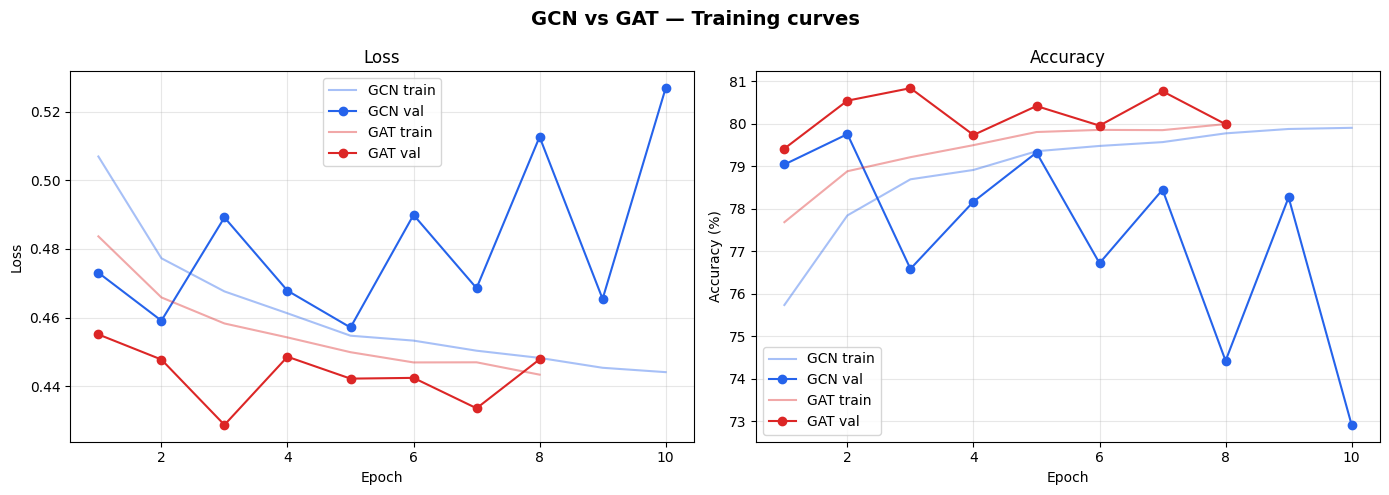

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [(hist_gcn, 'GCN', '#2563eb'), (hist_gat, 'GAT', '#dc2626')]:
    ep = range(1, len(hist['train_loss']) + 1)

    axes[0].plot(ep, hist['train_loss'], '-',  color=color, alpha=0.4, label=f'{label} train')
    axes[0].plot(ep, hist['val_loss'],   'o-', color=color, label=f'{label} val')

    axes[1].plot(ep, [a*100 for a in hist['train_acc']], '-',  color=color, alpha=0.4, label=f'{label} train')
    axes[1].plot(ep, [a*100 for a in hist['val_acc']],   'o-', color=color, label=f'{label} val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN vs GAT — Training curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Test set evaluation

In [10]:
@torch.no_grad()
def get_predictions(model, loader):
    """Returns y_true, y_pred, y_prob for a given model."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch)
        probs = F.softmax(out, dim=1)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_prob.extend(probs[:, 1].cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'AUC-ROC':   roc_auc_score(y_true, y_prob),
    }


yt_gcn, yp_gcn, yprob_gcn = get_predictions(model_gcn, test_loader)
yt_gat, yp_gat, yprob_gat = get_predictions(model_gat, test_loader)

metrics_gcn = compute_metrics(yt_gcn, yp_gcn, yprob_gcn)
metrics_gat = compute_metrics(yt_gat, yp_gat, yprob_gat)

In [11]:
# comparison table
print('\n' + '=' * 56)
print('         GCN vs GAT — TEST SET RESULTS')
print('=' * 56)
print(f'{"Metric":<14} | {"GCN":>12} | {"GAT":>12} | {"Winner":>10}')
print('-' * 56)
for key in metrics_gcn:
    g = metrics_gcn[key]
    a = metrics_gat[key]
    best = 'GAT' if a > g else ('GCN' if g > a else 'Tie')
    if key == 'AUC-ROC':
        print(f'{key:<14} | {g:>12.4f} | {a:>12.4f} | {best:>10}')
    else:
        print(f'{key:<14} | {g*100:>11.2f}% | {a*100:>11.2f}% | {best:>10}')
print('=' * 56)


         GCN vs GAT — TEST SET RESULTS
Metric         |          GCN |          GAT |     Winner
--------------------------------------------------------
Accuracy       |       79.08% |       80.24% |        GAT
Precision      |       76.40% |       83.56% |        GAT
Recall         |       85.31% |       76.24% |        GCN
F1-Score       |       80.61% |       79.73% |        GCN
AUC-ROC        |       0.8780 |       0.8799 |        GAT


## 10. ROC curves and confusion matrices

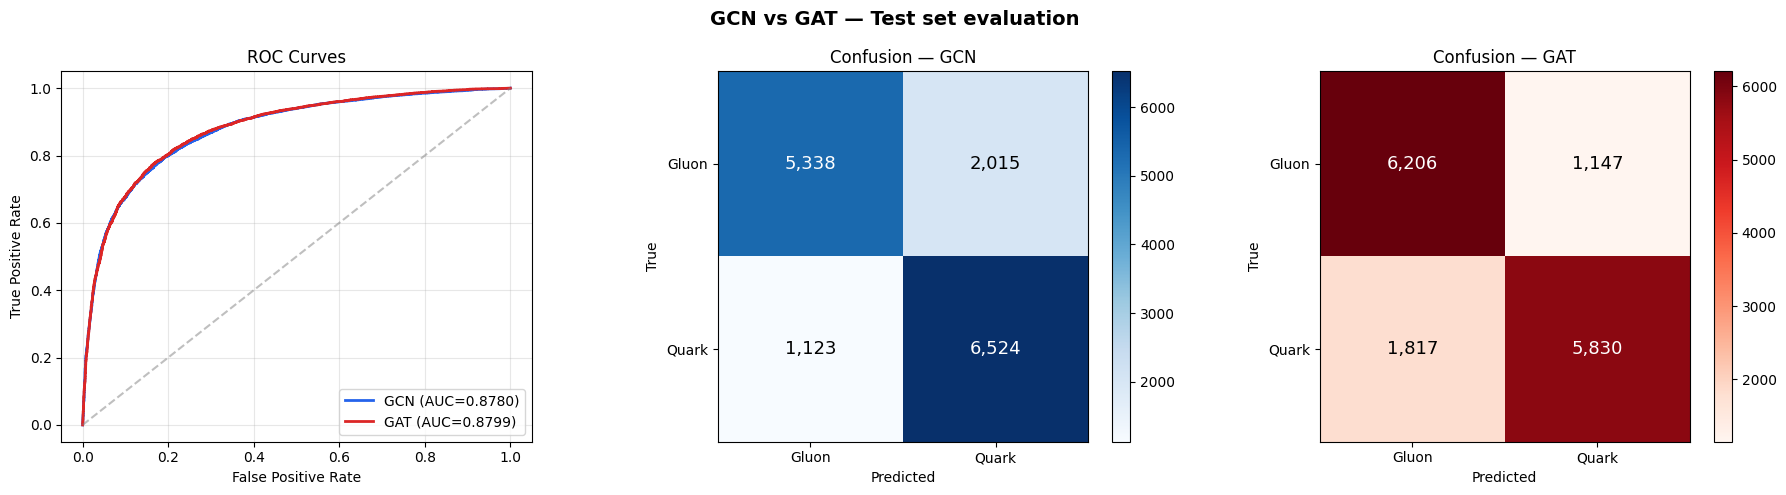

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for yp, label, color in [(yprob_gcn, 'GCN', '#2563eb'), (yprob_gat, 'GAT', '#dc2626')]:
    fpr, tpr, _ = roc_curve(yt_gcn, yp)
    auc_val = roc_auc_score(yt_gcn, yp)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={auc_val:.4f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# confusion matrices
for ax, ypred, name, color in [
    (axes[1], yp_gcn, 'GCN', 'Blues'),
    (axes[2], yp_gat, 'GAT', 'Reds')
]:
    cm = confusion_matrix(yt_gcn, ypred)
    im = ax.imshow(cm, cmap=color)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Gluon', 'Quark'])
    ax.set_yticklabels(['Gluon', 'Quark'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion — {name}')
    for i in range(2):
        for j in range(2):
            c = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', color=c, fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('GCN vs GAT — Test set evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Discussion: GCN vs GAT

**Graph construction choices.** Each jet is a variable-size point cloud of particles. We build a kNN graph (k=7) in the (eta, phi) plane because spatially close particles are more likely to share a common origin in the parton shower. We considered fully connected graphs but discarded them — they scale poorly with multiplicity and drown the useful local structure in noise from distant particles.

**GCN** uses isotropic aggregation: every neighbor contributes equally to the updated node embedding. This is simple and cheap (~50k parameters), but it can't distinguish which particles in the neighborhood matter more.

**GAT** learns attention weights for each edge, so it can focus on the most informative neighbors. This is especially relevant here because the discrimination between quark and gluon jets depends on subtle differences in the pT distribution and the angular spread of constituents. The attention mechanism lets the model learn to up-weight high-pT or peripheral particles, which carry the most discriminating information. The tradeoff is a higher parameter count (~200k with 4 heads).

In practice, we expect GAT to slightly outperform GCN on this task, mainly because the anisotropic aggregation is better suited to the heterogeneous nature of jet constituents.